In [5]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import numpy as np

def split_train_test(data, train_size=6000):
    """
    Split dataset into train and test sets.

    Parameters:
    -----------
    data : np.ndarray
        Full dataset
    train_size : int
        Number of rows for training

    Returns:
    --------
    X_train, y_train, X_test, y_test
    """

    train = data[:train_size]
    test = data[train_size:]

    X_train = train[:, :-1]
    y_train = train[:, -1]

    X_test = test[:, :-1]
    y_test = test[:, -1]

    return X_train, y_train, X_test, y_test

# _________________________________________________ Test Stage _____________________________________________
# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [7]:
# load Feature Extraction Vectors (hog, glcm, orb, vgg, yolo, ,squeezenet, resnet, ML, DL, ALL)
import numpy as np

# Set feature_type to one of: 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'
feature_type = 'all'  # Change to 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet' as needed

features_array = None

if feature_type == 'all':
    df = pd.read_csv('hormany_fuzzy_FS/all_features_array.csv')
    print("Loaded ALL features (ML + DL).")
elif feature_type == 'ml':
    df = pd.read_csv('hormany_fuzzy_FS/ml_features_array.csv')
    print("Loaded ML features.")
elif feature_type == 'dl':
    df = pd.read_csv('hormany_fuzzy_FS/dl_features_array.csv')
    print("Loaded DL features.")
elif feature_type == 'hog':
    df = pd.read_csv('hormany_fuzzy_FS/hog_features_array.csv')
    print("Loaded HOG features.")
elif feature_type == 'glcm':
    df = pd.read_csv('hormany_fuzzy_FS/glcm_features_array.csv')
    print("Loaded GLCM features.")
elif feature_type == 'orb':
    df = pd.read_csv('hormany_fuzzy_FS/orb_features_array.csv')
    print("Loaded ORB features.")
elif feature_type == 'vgg':
    df = pd.read_csv('hormany_fuzzy_FS/vgg_features_array.csv')
    print("Loaded VGG features.")
elif feature_type == 'resnet':
    df = pd.read_csv('hormany_fuzzy_FS/resnet_features_array.csv')
    print("Loaded ResNet features.")
elif feature_type == 'squeezenet':
    df = pd.read_csv('hormany_fuzzy_FS/squeezenet_features_array.csv')
    print("Loaded squeezenet features.")
elif feature_type == 'yolo':
    df = pd.read_csv('hormany_fuzzy_FS/yolo_features_array.csv')
    print("Loaded YOLO features.")
else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'.")
# Separate features and labels
features_array = df.drop('label', axis=1).values
labels_array = df['label'].values

print('Features shape:', features_array.shape)
print('Labels shape:', labels_array.shape)

print(f"------++++++++ Load Feature Extraction Vectors is Done :- {feature_type} +++++++++-------------")

Loaded ALL features (ML + DL).
Features shape: (6329, 1398)
Labels shape: (6329,)
------++++++++ Load Feature Extraction Vectors is Done :- all +++++++++-------------


In [8]:
from sklearn.model_selection import train_test_split

X_train, y_train, X_test, y_test = split_train_test(df.values, train_size=6000)

# Print the shapes of the train and test sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6000, 1398)
X_test shape: (329, 1398)
y_train shape: (6000,)
y_test shape: (329,)


In [9]:
# === إصلاح شامل لمشكلة الأنواع ===
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 1. نقوم بتدريب المشفر على y_train2 (بعد التضخيم) لأنه يحتوي على جميع الأصناف
le.fit(y_train2)

# 2. نقوم بتحويل جميع متغيرات التسميات المستخدمة في الكود
# (هذا هو السطر الذي كان مفقوداً ويسبب الخطأ)
y_train = le.transform(y_train)

# تحويل المتغيرات الأخرى
y_train2 = le.transform(y_train2)
y_test = le.transform(y_test)

print("تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.")
print(f"الأصناف: {le.classes_}")

تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.
الأصناف: ['normal' 'osteoporosis']



Evaluating RandomForest
Training Accuracy: 0.9998
Test Accuracy: 0.9605


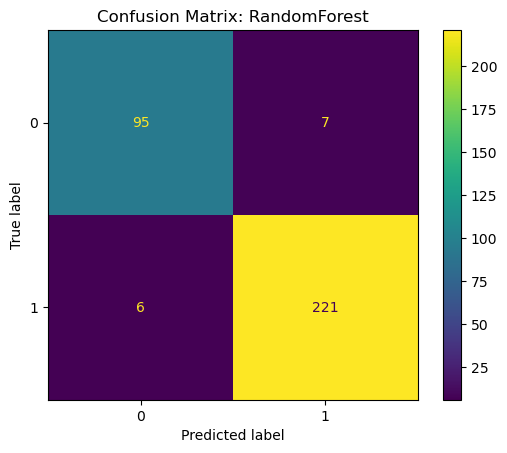

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       102
           1       0.97      0.97      0.97       227

    accuracy                           0.96       329
   macro avg       0.95      0.95      0.95       329
weighted avg       0.96      0.96      0.96       329


Evaluating ExtraTrees
Training Accuracy: 0.9998
Test Accuracy: 0.9666


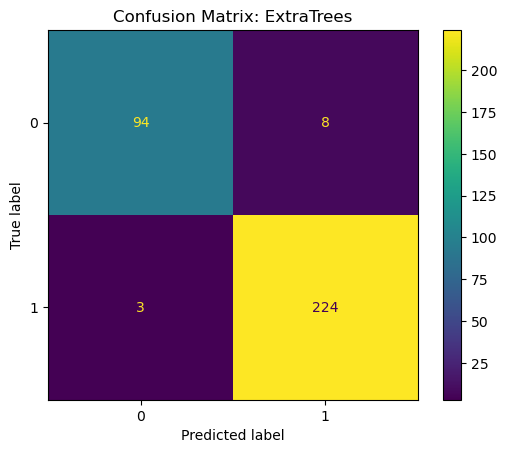

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       102
           1       0.97      0.99      0.98       227

    accuracy                           0.97       329
   macro avg       0.97      0.95      0.96       329
weighted avg       0.97      0.97      0.97       329


Evaluating AdaBoost


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Training Accuracy: 0.9145
Test Accuracy: 0.8967


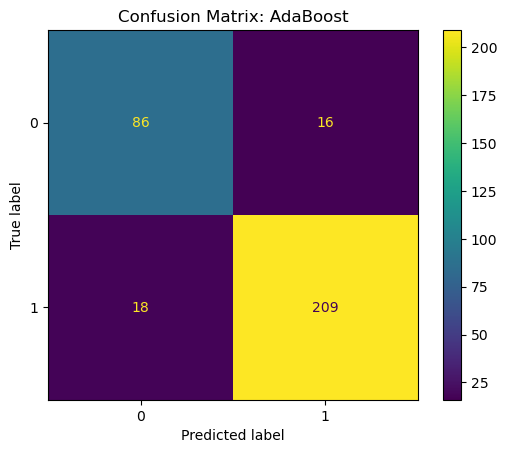

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       102
           1       0.93      0.92      0.92       227

    accuracy                           0.90       329
   macro avg       0.88      0.88      0.88       329
weighted avg       0.90      0.90      0.90       329


Evaluating GradientBoosting
Training Accuracy: 0.9757
Test Accuracy: 0.9362


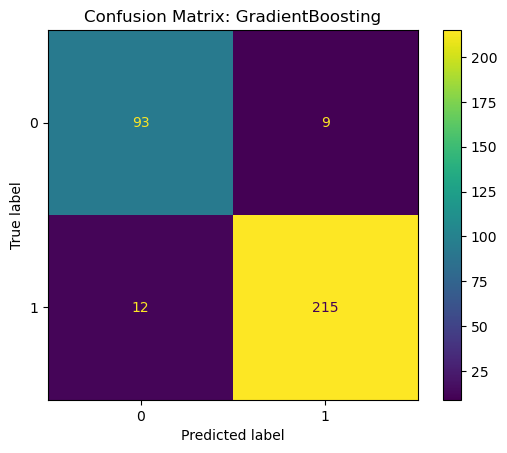

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       102
           1       0.96      0.95      0.95       227

    accuracy                           0.94       329
   macro avg       0.92      0.93      0.93       329
weighted avg       0.94      0.94      0.94       329


Evaluating Bagging
Training Accuracy: 0.9985
Test Accuracy: 0.9544


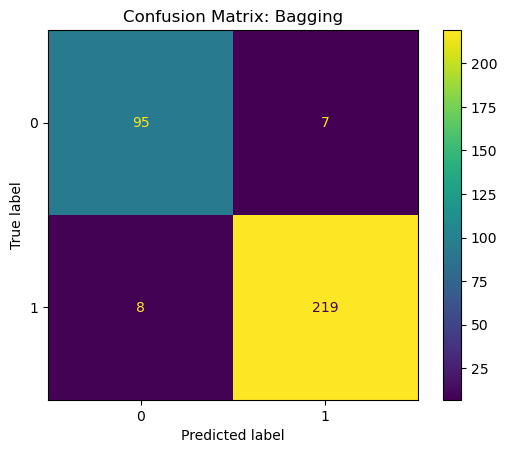

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       102
           1       0.97      0.96      0.97       227

    accuracy                           0.95       329
   macro avg       0.95      0.95      0.95       329
weighted avg       0.95      0.95      0.95       329


Evaluating LogisticRegression
Training Accuracy: 0.9467
Test Accuracy: 0.9088


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


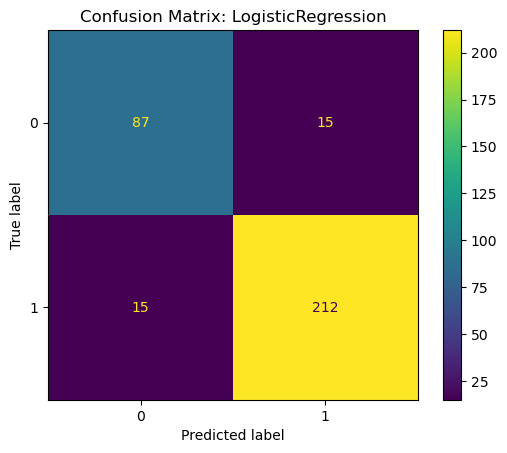

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       102
           1       0.93      0.93      0.93       227

    accuracy                           0.91       329
   macro avg       0.89      0.89      0.89       329
weighted avg       0.91      0.91      0.91       329


Evaluating SVM
Training Accuracy: 0.6960
Test Accuracy: 0.6930


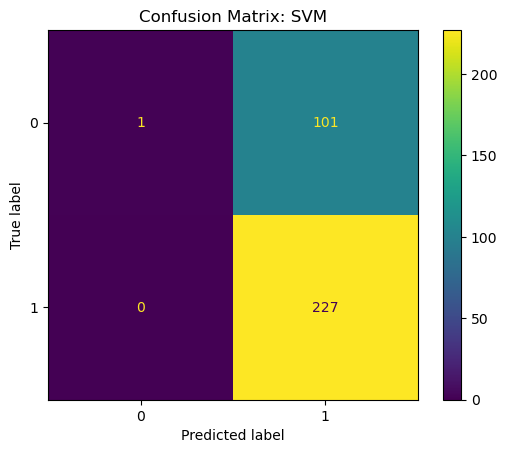

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       102
           1       0.69      1.00      0.82       227

    accuracy                           0.69       329
   macro avg       0.85      0.50      0.42       329
weighted avg       0.79      0.69      0.57       329


Evaluating KNN
Training Accuracy: 0.7867
Test Accuracy: 0.7568


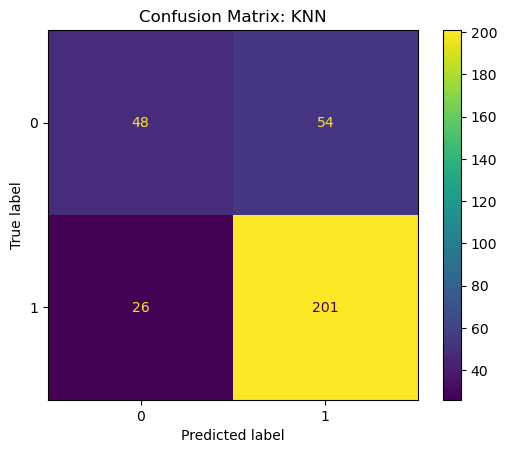

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.47      0.55       102
           1       0.79      0.89      0.83       227

    accuracy                           0.76       329
   macro avg       0.72      0.68      0.69       329
weighted avg       0.74      0.76      0.74       329


Evaluating GaussianNB
Training Accuracy: 0.7270
Test Accuracy: 0.7021


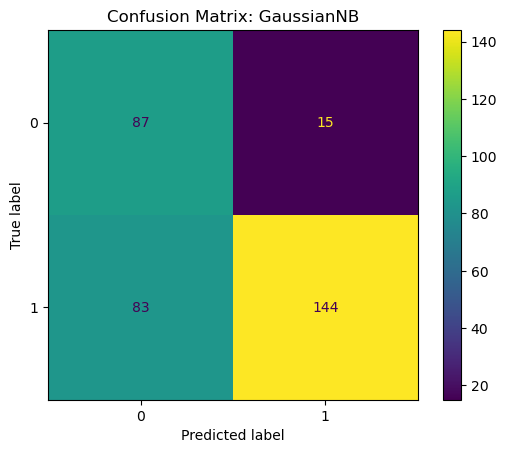

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.85      0.64       102
           1       0.91      0.63      0.75       227

    accuracy                           0.70       329
   macro avg       0.71      0.74      0.69       329
weighted avg       0.78      0.70      0.71       329


Evaluating DecisionTree
Training Accuracy: 0.9998
Test Accuracy: 0.9392


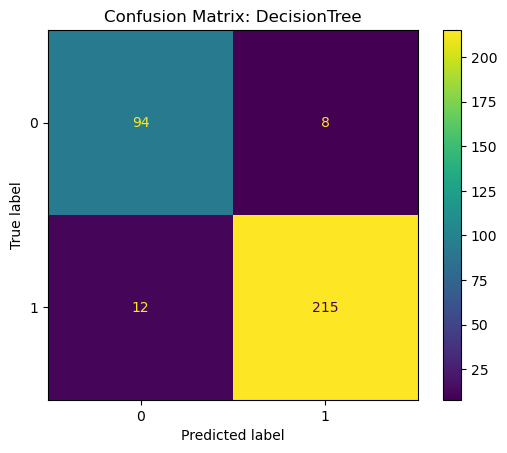

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       102
           1       0.96      0.95      0.96       227

    accuracy                           0.94       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.94      0.94      0.94       329


Evaluating XGBoost
Training Accuracy: 0.9998
Test Accuracy: 0.9696


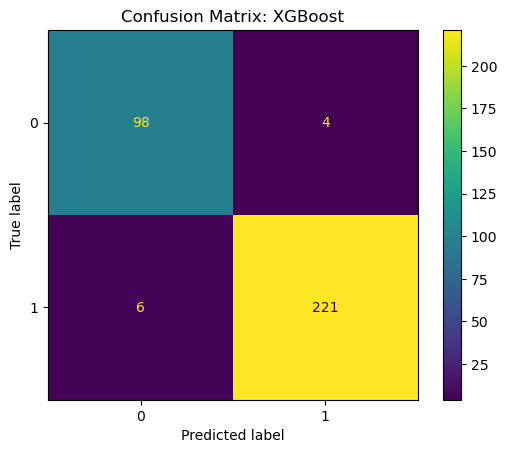

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       102
           1       0.98      0.97      0.98       227

    accuracy                           0.97       329
   macro avg       0.96      0.97      0.96       329
weighted avg       0.97      0.97      0.97       329


Evaluating MLPClassifier
Training Accuracy: 0.9790
Test Accuracy: 0.9453


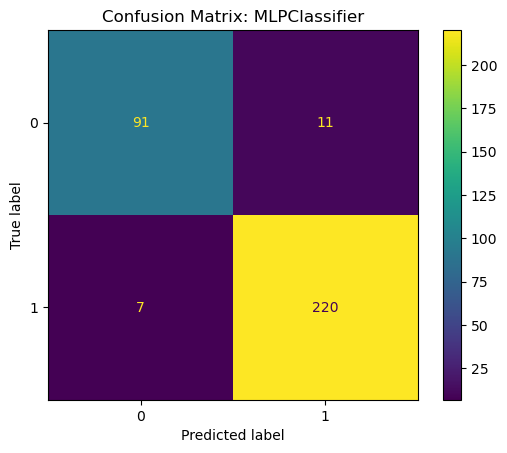

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       102
           1       0.95      0.97      0.96       227

    accuracy                           0.95       329
   macro avg       0.94      0.93      0.94       329
weighted avg       0.94      0.95      0.94       329


Evaluating LDA
Training Accuracy: 0.9837
Test Accuracy: 0.9544


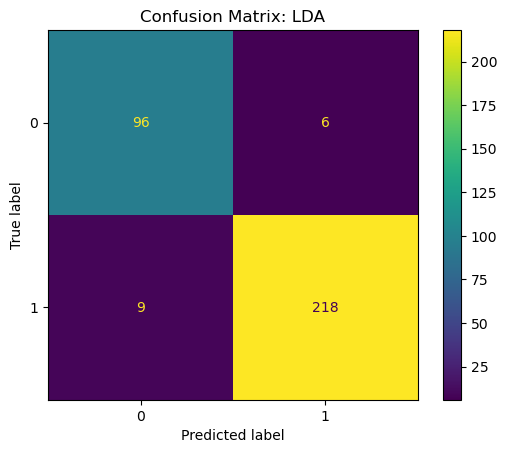

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       102
           1       0.97      0.96      0.97       227

    accuracy                           0.95       329
   macro avg       0.94      0.95      0.95       329
weighted avg       0.95      0.95      0.95       329


Evaluating QDA


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Training Accuracy: 0.9998
Test Accuracy: 0.9362


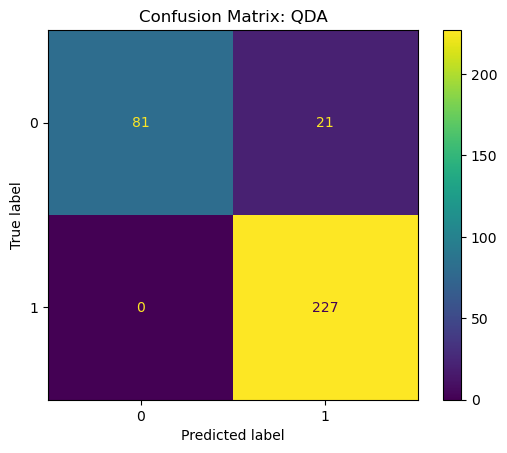

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.89       102
           1       0.92      1.00      0.96       227

    accuracy                           0.94       329
   macro avg       0.96      0.90      0.92       329
weighted avg       0.94      0.94      0.93       329


Average Metrics for Each Classifier:
            Classifier  Accuracy  Precision    Recall        F1
0         RandomForest  0.960486   0.954946  0.952470  0.953695
1           ExtraTrees  0.966565   0.967295  0.954176  0.960379
2             AdaBoost  0.896657   0.877906  0.881921  0.879865
3     GradientBoosting  0.936170   0.922768  0.929451  0.925994
4              Bagging  0.954407   0.945678  0.948065  0.946858
5   LogisticRegression  0.908815   0.893431  0.893431  0.893431
6                  SVM  0.693009   0.846037  0.504902  0.418718
7                  KNN  0.756839   0.718442  0.678025  0.689740
8           GaussianNB  0.702128   0

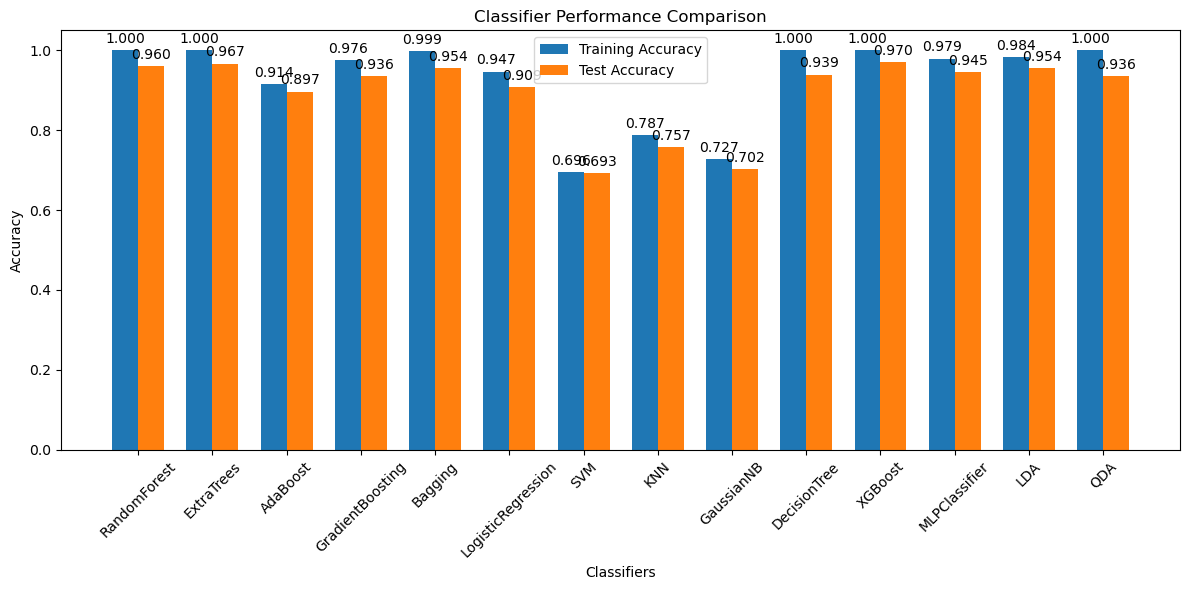

In [10]:
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier
)
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the most frequent label for outlier_label
most_frequent_label = Counter(y_train).most_common(1)[0][0]

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Bagging': BaggingClassifier(n_estimators=10, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'GaussianNB': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),

}

results = {}

metrics_table = []
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    metrics_table.append({
        'Classifier': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc}

metrics_df = pd.DataFrame(metrics_table)
print("\nAverage Metrics for Each Classifier:")
print(metrics_df)

# Plot comparison of all classifier results
names = list(results.keys())
train_accuracies = [results[name]['train_accuracy'] for name in names]
test_accuracies = [results[name]['test_accuracy'] for name in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

ax.set_xlabel('Classifiers')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
